In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
from mlxtend.preprocessing import TransactionEncoder
from tabulate import tabulate
import seaborn as sns

import collections
import warnings

import numpy as np
import pandas as pd

warnings.simplefilter("always", DeprecationWarning)

import random
import time

from itertools import groupby
import itertools

import math


In [94]:
# local file path
df = pd.read_csv('./market_basket_dataset.csv', sep=';', dtype={'BillNo': str}, low_memory=False)

# drop column unnamed (for general purpose)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

df


,BillNo,Itemname,Quantity,Price,CustomerID
0,1000,Apples,5,8.30,52299
1,1000,Butter,4,6.06,11752
2,1000,Eggs,4,2.66,16415
3,1000,Potatoes,4,8.10,22889
4,1004,Oranges,2,7.26,52255
...,...,...,...,...,...
495,1493,Juice,2,4.24,55321
496,1493,Bread,5,7.05,14479
497,1497,Coffee,3,2.01,25378
498,1497,Pasta,3,2.64,53334


In [95]:
def drawLine(length=40):
    print("─" * length)

In [96]:
#pengecekan tipe data
drawLine()
print("📋 DATA TYPES")
drawLine()
print(df.dtypes.to_string())
drawLine()

# Menghitung jumlah itemname
jumlah_itemname = df['Itemname'].nunique()
print("\n📦  JUMLAH ITEMNAME")
drawLine()
print(f"Total unik: {jumlah_itemname:,}")
drawLine()

# Menghitung jumlah BillNo/transaksi
jumlah_billno = df['BillNo'].nunique()
print("\n🧾  JUMLAH BILLNO / TRANSAKSI")
drawLine()
print(f"Total unik: {jumlah_billno:,}")
drawLine()

# Menampilkan daftar BillNo/transaksi
billno_list = df['BillNo'].unique()
print("\n🧾  DAFTAR BILLNO")
drawLine()
cols = 20
rows = (len(billno_list) + cols - 1) // cols
for r in range(rows):
    line = []
    for c in range(cols):
        idx = r + c * rows
        if idx < len(billno_list):
            line.append(f"{idx + 1:>3}. {billno_list[idx]}")
        else:
            line.append(" " * 12)
    print("  ".join(line))
drawLine()


────────────────────────────────────────
📋 DATA TYPES
────────────────────────────────────────
BillNo         object
Itemname       object
Quantity        int64
Price         float64
CustomerID      int64
────────────────────────────────────────

📦  JUMLAH ITEMNAME
────────────────────────────────────────
Total unik: 19
────────────────────────────────────────

🧾  JUMLAH BILLNO / TRANSAKSI
────────────────────────────────────────
Total unik: 153
────────────────────────────────────────

🧾  DAFTAR BILLNO
────────────────────────────────────────
  1. 1000    9. 1024   17. 1054   25. 1086   33. 1112   41. 1152   49. 1185   57. 1207   65. 1225   73. 1243   81. 1271   89. 1292   97. 1312  105. 1339  113. 1360  121. 1384  129. 1407  137. 1436  145. 1458  153. 1497
  2. 1004   10. 1027   18. 1056   26. 1088   34. 1115   42. 1153   50. 1186   58. 1211   66. 1226   74. 1250   82. 1279   90. 1293   98. 1313  106. 1343  114. 1367  122. 1385  130. 1409  138. 1437  146. 1461              
  3. 1005

In [97]:
# Pengecekan nilai kosong
drawLine()
print("🔍 Pengecekan Nilai Kosong (Missing Values)")
drawLine()
print(df.isnull().sum())

# Menampilkan Baris yang Mengandung Nilai Kosong (NaN)
print("\n")
drawLine()
print("⚠️  Baris yang Mengandung Nilai Kosong (NaN)")
drawLine()
print(df[df.isnull().any(axis=1)])

────────────────────────────────────────
🔍 Pengecekan Nilai Kosong (Missing Values)
────────────────────────────────────────
BillNo        0
Itemname      0
Quantity      0
Price         0
CustomerID    0
dtype: int64


────────────────────────────────────────
⚠️  Baris yang Mengandung Nilai Kosong (NaN)
────────────────────────────────────────
Empty DataFrame
Columns: [BillNo, Itemname, Quantity, Price, CustomerID]
Index: []


In [98]:
# Normalisasi nama barang ke huruf kecil
df['Itemname'] = df['Itemname'].str.lower()

# Mengelompokkan barang per transaksi (BillNo) 
transactions = df.groupby('BillNo')['Itemname'].apply(list).tolist()

# Tampilkan keranjang transaksi hasil pengelompokan
print("\n🛒  Keranjang Transaksi (setiap daftar = satu struk):\n")
# Build a clean table
table = [(f"T{idx:03d}", ", ".join(basket)) for idx, basket in enumerate(transactions, 1)]
print(tabulate(table, headers=["Transaksi", "Daftar Barang"], tablefmt="grid"))



🛒  Keranjang Transaksi (setiap daftar = satu struk):

+-------------+---------------------------------------------------------------------------------------------------+
| Transaksi   | Daftar Barang                                                                                     |
+=============+===================================================================================================+
| T001        | apples, butter, eggs, potatoes                                                                    |
+-------------+---------------------------------------------------------------------------------------------------+
| T002        | oranges                                                                                           |
+-------------+---------------------------------------------------------------------------------------------------+
| T003        | milk, onions, cereal                                                                              |
+-------------+--

# Tabu Search Preprocessing

In [99]:
# Fungsi Tabu Search (jalankan sebelum FP-Growth)
def tabu_search(transactions, max_iter=15, tabu_size=5, k=5, threshold=0.5):
    """
    Tabu Search untuk memilih k item fokus dari transaksi dan mem-filter
    transaksi sebelum FP-Growth.

    Args:
        transactions (List[List[str]]): daftar transaksi (list item per struk)
        max_iter (int): jumlah iterasi maksimal
        tabu_size (int): ukuran tabu list (tenure)
        k (int): jumlah item fokus yang dipilih
        threshold (float): minimum support relatif (0..1) untuk kandidat item

    Returns:
        dict: {
          'selected_items': List[str],
          'filtered_transactions': List[List[str]],
          'score': float
        }
    """
    from collections import Counter, deque
    from itertools import combinations

    n = len(transactions)
    if n == 0:
        return {'selected_items': [], 'filtered_transactions': [], 'score': 0.0}

    # Gunakan set per transaksi untuk menghitung presence dengan benar
    trx_sets = [set(t) for t in transactions]

    # Support single items (presence-based)
    item_counts = Counter()
    for s in trx_sets:
        item_counts.update(s)
    item_support = {it: item_counts[it] / n for it in item_counts}

    # Support pasangan (co-occurrence presence-based)
    pair_counts = Counter()
    for s in trx_sets:
        for a, b in combinations(sorted(s), 2):
            pair_counts[(a, b)] += 1
    pair_support = {p: pair_counts[p] / n for p in pair_counts}

    # Kandidat awal berdasar threshold; fallback jika kosong
    universe = [it for it, sup in item_support.items() if sup >= threshold]
    if not universe:
        universe = [it for it, _ in item_counts.most_common()]

    # Inisialisasi solusi dengan top-k by support
    init = [it for it, _ in sorted(((it, item_support[it]) for it in universe),
                                   key=lambda x: (-x[1], x[0]))][:k]
    S = set(init)

    # Objective: gabungan support rata-rata dan ko-occurrence internal
    def score_set(Sset):
        if not Sset:
            return 0.0
        Slist = sorted(Sset)
        s1 = sum(item_support.get(it, 0.0) for it in Slist) / len(Slist)
        if len(Slist) >= 2:
            pairs = list(combinations(Slist, 2))
            s2 = sum(pair_support.get(tuple(sorted(p)), 0.0) for p in pairs)
            s2 = s2 / len(pairs)
        else:
            s2 = 0.0
        # Bobot (bisa di-tune)
        return 0.6 * s1 + 0.4 * s2

    best_S = set(S)
    best_score = score_set(best_S)

    tabu = deque(maxlen=tabu_size)

    for iter_count in range(max_iter):
        current_best_neighbor = None
        current_best_move = None
        current_best_score = -1.0

        # Generate neighbors: add/remove/swap
        # ADD
        if len(S) < k:
            for x in universe:
                if x in S:
                    continue
                move_token = ("add", x)
                cand = set(S)
                cand.remove(i)
                cand.add(x)
                sc = score_set(cand)
                if move_token in tabu and sc <= best_score:
                    continue  # tabu, tidak memenuhi aspiration
                if sc > current_best_score:
                    current_best_score = sc
                    current_best_neighbor = cand
                    current_best_move = move_token

        # REMOVE
        for i in list(S):
            move_token = ("remove", i)
            cand = set(S)
            cand.remove(i)
            sc = score_set(cand)
            if move_token in tabu and sc <= best_score:
                continue
            if sc > current_best_score:
                current_best_score = sc
                current_best_neighbor = cand
                current_best_move = move_token

        # SWAP
        for i in list(S):
            for x in universe:
                if x in S:
                    continue
                move_token = ("swap", i, x)
                cand = set(S)
                if len(cand) < k:
                    cand.add(x)
                sc = score_set(cand)
                if move_token in tabu and sc <= best_score:
                    continue
                if sc > current_best_score:
                    current_best_score = sc
                    current_best_neighbor = cand
                    current_best_move = move_token

        # Jika tak ada neighbor valid, berhenti
        if current_best_neighbor is None:
            print(f"[iter {iter_count}] no valid neighbor, stopping")
            break

        # Apply move
        S = current_best_neighbor
        tabu.append(current_best_move)

        # Update best (global)
        if current_best_score > best_score:
            best_S = set(S)
            best_score = current_best_score
            print(f"[iter {iter_count}] new best score={best_score:.4f} move={current_best_move}")
        else:
            print(f"[iter {iter_count}] accepted move={current_best_move} score={current_best_score:.4f}")

    # Filter transaksi ke item terpilih
    selected_items = sorted(best_S)
    filtered = []
    for t in transactions:
        print(f"[debug] t={t}")
        ft = [it for it in t if it in best_S]
        if ft:
            filtered.append(ft)

    return {
        'selected_items': selected_items,
        'filtered_transactions': filtered,
        'score': best_score
    }

In [100]:
df['Itemname'] = df['Itemname'].str.lower()

# Mengelompokkan barang per transaksi (BillNo)
transactions = df.groupby('BillNo')['Itemname'].apply(list).tolist()

In [122]:
tabu_out = tabu_search(transactions, max_iter=10, tabu_size=18, k=10, threshold=0.8)
transactions_tabu = tabu_out['filtered_transactions']
selected_items = tabu_out['selected_items']
print("\n🔧 Tabu Search: item terpilih →", ", ".join(selected_items))
print(f"Total transaksi setelah filter: {len(transactions_tabu)} dari {len(transactions)}")

[iter 0] new best score=0.1338 move=('remove', 'sugar')
[iter 1] new best score=0.1360 move=('remove', 'yogurt')
[iter 2] new best score=0.1386 move=('remove', 'eggs')
[iter 3] new best score=0.1417 move=('remove', 'tomatoes')
[iter 4] new best score=0.1446 move=('remove', 'potatoes')
[iter 5] new best score=0.1483 move=('remove', 'oranges')
[iter 6] new best score=0.1521 move=('remove', 'cheese')
[iter 7] new best score=0.1569 move=('remove', 'coffee')
[iter 8] accepted move=('add', 'coffee') score=0.1529
[iter 9] accepted move=('swap', 'coffee', 'cereal') score=0.1521
[debug] t=['apples', 'butter', 'eggs', 'potatoes']
[debug] t=['oranges']
[debug] t=['milk', 'onions', 'cereal']
[debug] t=['tomatoes', 'potatoes', 'cereal']
[debug] t=['bananas']
[debug] t=['tomatoes']
[debug] t=['pasta', 'onions', 'bread', 'bananas', 'coffee', 'sugar', 'potatoes', 'oranges']
[debug] t=['bananas', 'oranges', 'potatoes']
[debug] t=['chicken', 'cereal', 'bananas']
[debug] t=['cheese', 'pasta', 'cereal', '

In [123]:
# Encode transaksi ke format biner
te = TransactionEncoder()
te_ary = te.fit(transactions_tabu).transform(transactions_tabu)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# Tampilan hasil data encoding
drawLine()
print("TRANSACTION ENCODER RESULTS - BINARY FORMAT")
drawLine()
print(f"Dataset Shape: {df_encoded.shape[0]} transaksi × {df_encoded.shape[1]} item")
print("\n10 Data Pertama:")
drawLine()

print(tabulate(df_encoded.head(10), headers='keys', tablefmt='grid', showindex=True)) # 1 = True, 0 = False

────────────────────────────────────────
TRANSACTION ENCODER RESULTS - BINARY FORMAT
────────────────────────────────────────
Dataset Shape: 59 transaksi × 2 item

10 Data Pertama:
────────────────────────────────────────
+----+-----------+----------+
|    |   bananas |   cereal |
+====+===========+==========+
|  0 |         0 |        1 |
+----+-----------+----------+
|  1 |         0 |        1 |
+----+-----------+----------+
|  2 |         1 |        0 |
+----+-----------+----------+
|  3 |         1 |        0 |
+----+-----------+----------+
|  4 |         1 |        0 |
+----+-----------+----------+
|  5 |         1 |        1 |
+----+-----------+----------+
|  6 |         1 |        1 |
+----+-----------+----------+
|  7 |         0 |        1 |
+----+-----------+----------+
|  8 |         0 |        1 |
+----+-----------+----------+
|  9 |         1 |        0 |
+----+-----------+----------+


## Manual Algorithm FP Growth

### Configure FP Common Algorithm

In [124]:
def setup_fptree(df, min_support):
    """
    Membangun struktur FP-Tree dari DataFrame transaksi.
    
    Langkah-langkah:
    1. Hitung jumlah transaksi (baris).
    2. Deteksi apakah DataFrame dalam format sparse.
    3. Buat matriks 'disabled' untuk menandai nilai yang hilang (NaN) atau tidak valid.
    4. Hitung support relatif setiap item dengan mengabaikan baris yang disabled.
    5. Filter item yang memenuhi min_support.
    6. Urutkan item berdasarkan support (descending) untuk pembangunan tree.
    7. Bangun FP-Tree dengan memasukkan setiap transaksi yang sudah difilter dan diurutkan.
    
    Returns:
        tree: objek FPTree yang sudah terisi
        disabled: ndarray penanda baris/item yang tidak valid
        rank: dict pemetaan item ke urutan prioritas
    """
    num_itemsets = len(df.index)

    # Deteksi format sparse
    is_sparse = False
    if hasattr(df, "sparse"):
        if df.size == 0:
            itemsets = df.values
        else:
            itemsets = df.sparse.to_coo().tocsr()
            is_sparse = True
    else:
        itemsets = df.values

    # Buat masker untuk nilai yang hilang / tidak valid
    disabled = df.copy()
    disabled = np.where(pd.isna(disabled), 1, np.nan) + np.where(
        (disabled == 0) | (disabled == 1), np.nan, 0
    )

    # Hitung support tiap item dengan mengabaikan baris disabled
    item_support = np.array(
        np.nansum(df.values, axis=0)
        / (float(num_itemsets) - np.nansum(disabled, axis=0))
    )
    item_support = item_support.reshape(-1)
    items = np.nonzero(item_support >= min_support)[0]

    # Urutkan item berdasarkan support (descending)
    indices = item_support[items].argsort()
    rank = {item: i for i, item in enumerate(items[indices])}

    # Hapus nilai nol pada sparse matrix untuk efisiensi
    if is_sparse:
        itemsets.eliminate_zeros()

    # Bangun FP-Tree
    tree = FPTree(rank)
    for i in range(num_itemsets):
        if is_sparse:
            nonnull = itemsets.indices[itemsets.indptr[i] : itemsets.indptr[i + 1]]
        else:
            nonnull = np.where(itemsets[i, :])[0]
        # Filter item yang memenuhi min_support lalu urutkan sesuai rank
        itemset = [item for item in nonnull if item in rank]
        itemset.sort(key=rank.get, reverse=True)
        tree.insert_ordered_itemset(itemset)

    return tree, disabled, rank


def generate_itemsets_with_supports(generator, df, disabled, min_support, num_itemsets, colname_map):
    """
    Menghasilkan daftar itemset beserta nilai support-nya dari generator pola yang ditemukan.
    
    Langkah-langkah:
    1. Iterasi setiap (support, itemset) dari generator.
    2. Hitung support yang sudah dikoreksi dengan mengabaikan baris disabled.
       - Untuk itemset tunggal: langsung kurangi jumlah disabled.
       - Untuk itemset >1: periksa tiap baris, hitung penyebut (baris yang valid) dan pembilang (itemset yang valid).
    3. Filter hasil akhir yang memenuhi min_support.
    4. (Opsional) ubah nama kolom sesuai pemetaan yang diberikan.
    
    Returns:
        DataFrame dengan kolom 'support' dan 'itemsets'
    """
    itemsets = []
    supports = []
    for sup, iset in generator:
        itemsets.append(frozenset(iset))
        dec = disabled[:, iset]
        _dec = df.values[:, iset]

        if len(iset) == 1:
            supports.append((sup - np.nansum(dec)) / (num_itemsets - np.nansum(dec)))

        elif len(iset) > 1:
            denom = 0
            num = 0
            for i in range(dec.shape[0]):
                item_dsbl = list(dec[i, :])
                item_orig = list(_dec[i, :])

                if 1 in set(item_dsbl):
                    denom += 1

                    if (0 not in set(item_orig)) or (
                        all(np.isnan(x) for x in item_orig)
                    ):
                        num -= 1

            if num_itemsets - denom == 0:
                supports.append(0)
            else:
                supports.append((sup + num) / (num_itemsets - denom))

    res_df = pd.DataFrame({"support": supports, "itemsets": itemsets})
    res_df = res_df[res_df["support"] >= min_support]

    if colname_map is not None:
        res_df["itemsets"] = res_df["itemsets"].apply(
            lambda x: frozenset([colname_map[i] for i in x])
        )

    return res_df


def check_valid_input(df, null_values=False):
    """
    Validasi keabsahan DataFrame input.
    
    Langkah-langkah:
    1. Lewati jika df None.
    2. Tolak SparseDataFrame yang sudah deprecated.
    3. Untuk sparse matrix, pastikan nama kolom string atau dimulai 0.
    4. Periksa tipe data: semua kolom harus boolean (atau boleh NaN bila null_values=True).
    5. Beri peringatan jika ada tipe non-bool.
    6. Pastikan nilai hanya 0, 1, True, False, (dan NaN bila null_values=True).
    
    Raises:
        TypeError, ValueError bila input tidak valid.
    """
    if df is None:
        return

    # Blokir SparseDataFrame deprecated
    if f"{type(df)}" == "<class 'pandas.core.frame.SparseDataFrame'>":
        msg = (
            "SparseDataFrame sudah kedaluwarsa. Gunakan DataFrame biasa dengan kolom sparse."
        )
        raise TypeError(msg)

    if df.size == 0:
        return
    if hasattr(df, "sparse"):
        if not isinstance(df.columns[0], str) and df.columns[0] != 0:
            raise ValueError(
                "Pembatasan Pandas: nama kolom bertipe int harus diawali 0 atau ubah jadi string: "
                "`df.columns = [str(i) for i in df.columns]`."
            )

    # Cek tipe data: semua boolean (ataboleh NaN bila null_values=True)
    if null_values:
        all_bools = (
            df.apply(lambda col: col.apply(lambda x: pd.isna(x) or isinstance(x, bool)))
            .all()
            .all()
        )
    else:
        all_bools = df.dtypes.apply(pd.api.types.is_bool_dtype).all()

    if not all_bools:
        warnings.warn(
            "Tipe data non-bool memperlambat komputasi. "
            "Gunakan DataFrame bertipe bool.",
            DeprecationWarning,
        )

        has_nans = pd.isna(df).any().any()
        if null_values and not has_nans:
            warnings.warn(
                "null_values=True lambat bila tak ada NaN. Gunakan False."
            )
        if not null_values and has_nans:
            raise ValueError(
                "NaN values are not permitted"
            )

        # Ambil nilai aktual untuk dicek
        if hasattr(df, "sparse"):
            if df.size == 0:
                values = df.values
            else:
                values = df.sparse.to_coo().tocoo().data
        else:
            values = df.values

        if null_values:
            idxs = np.where((values != 1) & (values != 0) & (~np.isnan(values)))
        else:
            idxs = np.where((values != 1) & (values != 0))

        if len(idxs[0]) > 0:
            val = values[tuple(loc[0] for loc in idxs)]
            s = (
                "The allowed values for a DataFrame"
                " are True, False, 0, 1. Found value %s" % (val)
            )

            if null_values:
                s = (
                    "The allowed values for a DataFrame"
                    " are True, False, 0, 1, NaN. Found value %s" % (val)
                )
            raise ValueError(s)


class FPTree(object):
    """
    Struktur data FP-Tree untuk menyimpan transaksi dalam bentuk pohon.
    Setiap node merepresentasikan item dengan count tertentu.
    """
    def __init__(self, rank=None):
        # Root node virtual (item=None)
        self.root = FPNode(None)
        # Dictionary menampung daftar node per item
        self.nodes = collections.defaultdict(list)
        # Item kondisi untuk conditional tree
        self.cond_items = []
        # Urutan prioritas item (support descending)
        self.rank = rank

    def conditional_tree(self, cond_item, minsup):
        """
        Bangun conditional FP-Tree untuk item tertentu.
        
        Langkah-langkah:
        1. Kumpulkan semua path dari root ke node cond_item.
        2. Hitung count tiap item pada path-path tersebut.
        3. Filter item yang memenuhi minsup.
        4. Bangun conditional tree baru dengan item yang sudah difilter & diurutkan.
        
        Returns:
            FPTree baru yang dikondisikan pada cond_item
        """
        branches = []
        count = collections.defaultdict(int)
        for node in self.nodes[cond_item]:
            branch = node.get_item_path_from_root()
            branches.append(branch)
            for item in branch:
                count[item] += node.count

        # Item yang memenuhi minsup, diurutkan ascending (untuk kemudahan)
        items = [item for item in count if count[item] >= minsup]
        items.sort(key=count.get)
        rank = {item: i for i, item in enumerate(items)}

        # Bangun conditional tree
        cond_tree = FPTree(rank)
        for idx, branch in enumerate(branches):
            branch = sorted(
                [i for i in branch if i in rank], key=rank.get, reverse=True
            )
            cond_tree.insert_ordered_itemset(branch, self.nodes[cond_item][idx].count)
        cond_tree.cond_items = self.cond_items + [cond_item]

        return cond_tree

    def insert_ordered_itemset(self, itemset, count=1):
        """
        Masukkan itemset (urutan menurun support) ke dalam tree.
        
        Langkah-langkah:
        1. Naikkan count root.
        2. Untuk setiap item, jika child sudah ada naikkan count, jika tidak buat node baru.
        3. Simpan node pada dictionary nodes untuk akses cepat.
        """
        self.root.count += count

        if len(itemset) == 0:
            return

        index = 0
        node = self.root
        for item in itemset:
            if item in node.children:
                child = node.children[item]
                child.count += count
                node = child
                index += 1
            else:
                break

        # Sisanya buat cabang baru
        for item in itemset[index:]:
            child_node = FPNode(item, count, node)
            self.nodes[item].append(child_node)
            node = child_node

    def is_single_path(self):
        """
        Cek apakah tree hanya berisi satu path lurus (untuk optimasi mining).
        
        Returns:
            bool: True bila tree hanya satu jalur dari root ke leaf
        """
        if len(self.root.children) > 1:
            return False
        for i in self.nodes:
            if len(self.nodes[i]) > 1 or len(self.nodes[i][0].children) > 1:
                return False
        return True

    def print_status(self, count, colnames):
        """
        Cetak status proses mining untuk debugging.
        
        Args:
            count: jumlah itemset yang sudah ditemukan
            colnames: dict pemetaan index ke nama kolom
        """
        cond_items = [str(i) for i in self.cond_items]
        if colnames:
            cond_items = [str(colnames[i]) for i in self.cond_items]
        cond_items = ", ".join(cond_items)
        print(
            "\r%d itemset dari tree yang dikondisikan pada item (%s)" % (count, cond_items),
            end="\n",
        )


class FPNode(object):
    """
    Node individual di dalam FP-Tree.
    """
    def __init__(self, item, count=0, parent=None):
        self.item = item          # Nama item (None untuk root)
        self.count = count        # Jumlah transaksi yang melewati node ini
        self.parent = parent      # Node induk
        self.children = collections.defaultdict(FPNode)  # Child nodes

        if parent is not None:
            parent.children[item] = self

    def get_item_path_from_root(self):
        """
        Ambil path item dari root (tidak termasuk node ini) dalam urutan root -> ... -> parent.
        
        Returns:
            list: item-item pada jalur, sudah diurutkan dari root
        """
        path = []
        if self.item is None:
            return path

        node = self.parent
        while node.item is not None:
            path.append(node.item)
            node = node.parent

        path.reverse()
        return path

### Configure FP Growth Algorithm

In [125]:
def fpgrowth(
    df, min_support=0.5, null_values=False, use_colnames=False, max_len=None, verbose=0
):
    # Langkah 1: Validasi DataFrame masukan dan flag penanganan nilai null
    check_valid_input(df, null_values)

    # Langkah 2: Pastikan min_support berada dalam rentang yang valid (0, 1]
    if min_support <= 0.0:
        raise ValueError(
            "`min_support` harus angka positif "
            "dalam interval `(0, 1]`. "
            "Didapat %s." % min_support
        )

    # Langkah 3: Bangun pemetaan nama kolom jika pengguna ingin menyimpan nama kolom asli
    colname_map = None
    if use_colnames:
        colname_map = {idx: item for idx, item in enumerate(df.columns)}

    # Langkah 4: Bangun FP-tree dan identifikasi item yang dinonaktifkan (di bawah min_support)
    tree, disabled, _ = setup_fptree(df, min_support)

    # Langkah 5: Ubah min_support relatif menjadi hitungan absolut
    minsup = math.ceil(min_support * len(df.index))

    # Langkah 6: Buat generator yang secara malas menghasilkan itemset yang sering
    generator = fpg_step(tree, minsup, colname_map, max_len, verbose)

    # Langkah 7: Pasca-proses generator untuk melampirkan nilai support dan kembalikan hasil akhir
    return generate_itemsets_with_supports(
        generator, df, disabled, min_support, len(df.index), colname_map
    )


def fpg_step(tree, minsup, colnames, max_len, verbose):
    # Langkah 1: Inisialisasi penghitung untuk itemset yang dihasilkan dan ambil item tree saat ini
    count = 0
    items = tree.nodes.keys()

    # Langkah 2: Tangani kasus khusus ketika FP-tree berupa jalur tunggal
    if tree.is_single_path():
        # Tentukan ukuran kombinasi maksimal dengan memperhatikan batasan max_len
        size_remain = len(items) + 1
        if max_len:
            size_remain = max_len - len(tree.cond_items) + 1
        # Hasilkan semua kombinasi non-kosong dari item pada jalur
        for i in range(1, size_remain):
            for itemset in itertools.combinations(items, i):
                count += 1
                # Kombinasi adalah hitungan minimum dari item-itemnya
                support = min([tree.nodes[i][0].count for i in itemset])
                yield support, tree.cond_items + list(itemset)

    # Langkah 3: Jika tree bukan jalur tunggal, hasilkan setiap perluasan item
    elif not max_len or max_len > len(tree.cond_items):
        for item in items:
            count += 1
            # Agregasikan support untuk item di semua nodenya
            support = sum([node.count for node in tree.nodes[item]])
            yield support, tree.cond_items + [item]

    # Langkah 4: print
    if verbose:
        tree.print_status(count, colnames)

    # Langkah 5: Secara rekursif jalankan FP-tree bersyarat untuk setiap item
    if not tree.is_single_path() and (not max_len or max_len > len(tree.cond_items)):
        for item in items:
            # Bangun FP-tree bersyarat untuk item saat ini
            cond_tree = tree.conditional_tree(item, minsup)
            # Secara rekursif hasilkan itemset yang sering dari tree bersyarat
            for sup, iset in fpg_step(cond_tree, minsup, colnames, max_len, verbose):
                yield sup, iset

### Implementation FP Growth


Hasil Frequent Itemset dengan nilai support: 

     support           itemsets
0  0.525424           (cereal)
1  0.627119          (bananas)
2  0.152542  (cereal, bananas)


/var/folders/qk/p1xn12n13qb82ww1m9ffhlkm0000gn/T/ipykernel_22420/1440687802.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='support', y='itemsets', data=frequent_itemsets_sorted, palette='viridis')


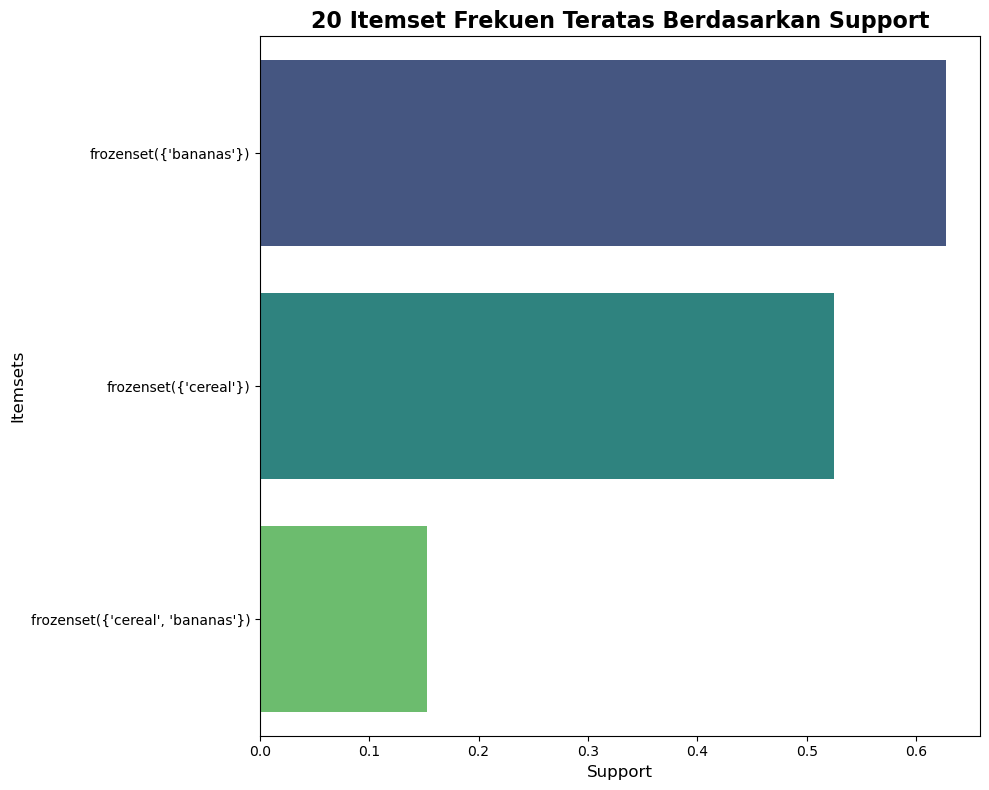

In [126]:
# Hitung frequent itemsets dengan nilai support
frequent_itemsets = fpgrowth(df_encoded, min_support=0.001, use_colnames=True)
print("\nHasil Frequent Itemset dengan nilai support: \n\n", frequent_itemsets)

frequent_itemsets_sorted = frequent_itemsets.sort_values(by='support', ascending=False).head(20)
# Grafik Horizontal
plt.figure(figsize=(10, 8))
sns.barplot(x='support', y='itemsets', data=frequent_itemsets_sorted, palette='viridis')
plt.title('20 Itemset Frekuen Teratas Berdasarkan Support', fontsize=16, fontweight='bold')
plt.xlabel('Support', fontsize=12)
plt.ylabel('Itemsets', fontsize=12)
plt.tight_layout()
plt.show()


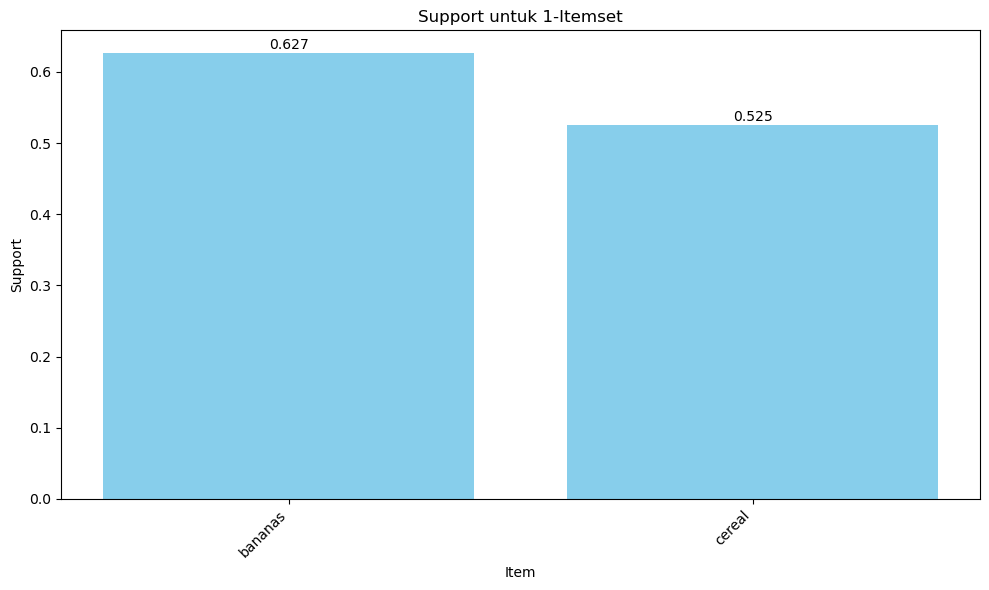

In [59]:
# mengurutkan berdasarkan prioritas 1-itemset
single_items = frequent_itemsets[frequent_itemsets['itemsets'].apply(lambda x: len(x) == 1)]

single_items_sorted = single_items.sort_values(by='support', ascending=False)

# Menampilkan grafik batang dengan keterangan
import matplotlib.pyplot as plt

labels = [list(item)[0] for item in single_items_sorted['itemsets']]
supports = single_items_sorted['support'].values

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, supports, color='skyblue')

# Keterangan
plt.xlabel('Item')
plt.ylabel('Support')
plt.title('Support untuk 1-Itemset')
plt.xticks(rotation=45, ha='right')

for bar, sup in zip(bars, supports):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{sup:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


## CBP (Conditional Pattern Base)

In [61]:
transactions_tabu_temp = transactions_tabu.copy()

In [62]:
transactions_tabu

[['cereal'],
 ['cereal'],
 ['bananas'],
 ['bananas'],
 ['bananas'],
 ['cereal', 'bananas'],
 ['cereal', 'bananas'],
 ['cereal'],
 ['cereal'],
 ['bananas'],
 ['bananas', 'cereal'],
 ['bananas'],
 ['bananas'],
 ['bananas'],
 ['cereal'],
 ['bananas'],
 ['bananas'],
 ['bananas'],
 ['bananas'],
 ['bananas'],
 ['bananas'],
 ['cereal'],
 ['cereal'],
 ['bananas'],
 ['cereal'],
 ['cereal'],
 ['cereal'],
 ['cereal'],
 ['bananas'],
 ['bananas'],
 ['bananas'],
 ['bananas', 'cereal'],
 ['cereal', 'bananas'],
 ['cereal'],
 ['cereal'],
 ['bananas'],
 ['bananas'],
 ['bananas'],
 ['bananas'],
 ['cereal'],
 ['cereal'],
 ['cereal'],
 ['cereal'],
 ['cereal'],
 ['cereal'],
 ['bananas'],
 ['bananas'],
 ['cereal'],
 ['cereal'],
 ['bananas'],
 ['cereal'],
 ['bananas'],
 ['cereal', 'bananas'],
 ['bananas', 'cereal'],
 ['bananas'],
 ['cereal', 'bananas'],
 ['cereal', 'bananas'],
 ['bananas'],
 ['bananas']]

In [67]:
# Tujuan: Membangun Conditional Pattern Base (CPB) untuk setiap 1-itemset
#          – himpunan jalur prefiks yang muncul bersama item tertentu.
#          CPB ini menjadi masukan untuk menambang pola frekuensi dengan FP-Growth.
from collections import defaultdict

# 1: Hitung frekuensi global setiap item
item_counts = defaultdict(int)
for transaction in transactions_tabu:
    for item in transaction:
        item_counts[item] += 1

# 2: Hapus item di bawah ambang minimum support
min_support = 0.01 * len(transactions_tabu)
item_counts = {item: count for item, count in item_counts.items() if count >= min_support}

print("item_counts:", item_counts)
# 3: Urutkan item yang tersisa secara menurun berdasarkan frekuensi
def sort_items(transactions_tabu):
    return sorted([item for item in transactions_tabu if item in item_counts],
            key=lambda item: (-item_counts[item], item))

sorted_transactions = [sort_items(t) for t in transactions_tabu]

print("sorted_transactions:", sorted_transactions)

item_counts: {'cereal': 31, 'bananas': 37}
sorted_transactions: [['cereal'], ['cereal'], ['bananas'], ['bananas'], ['bananas'], ['bananas', 'cereal'], ['bananas', 'cereal'], ['cereal'], ['cereal'], ['bananas'], ['bananas', 'cereal'], ['bananas'], ['bananas'], ['bananas'], ['cereal'], ['bananas'], ['bananas'], ['bananas'], ['bananas'], ['bananas'], ['bananas'], ['cereal'], ['cereal'], ['bananas'], ['cereal'], ['cereal'], ['cereal'], ['cereal'], ['bananas'], ['bananas'], ['bananas'], ['bananas', 'cereal'], ['bananas', 'cereal'], ['cereal'], ['cereal'], ['bananas'], ['bananas'], ['bananas'], ['bananas'], ['cereal'], ['cereal'], ['cereal'], ['cereal'], ['cereal'], ['cereal'], ['bananas'], ['bananas'], ['cereal'], ['cereal'], ['bananas'], ['cereal'], ['bananas'], ['bananas', 'cereal'], ['bananas', 'cereal'], ['bananas'], ['bananas', 'cereal'], ['bananas', 'cereal'], ['bananas'], ['bananas']]


In [68]:
# 4: FP-Tree
class FPNode:
    def __init__(self, item, count=1):
        self.item = item
        self.count = count
        self.children = {}
        self.parent = None

class FPTree:
    def __init__(self):
        self.root = FPNode(None)
        self.headers = defaultdict(list)

    def insert(self, transaction):
        current = self.root
        for item in transaction:
            if item in current.children:
                current.children[item].count += 1
            else:
                new_node = FPNode(item)
                new_node.parent = current
                current.children[item] = new_node
                self.headers[item].append(new_node)
            current = current.children[item]

    def conditional_pattern_base(self, item):
        patterns = []
        for node in self.headers[item]:
            path = []
            current = node.parent
            while current and current.item is not None:
                path.append(current.item)
                current = current.parent
            if path:
                patterns.append((list(reversed(path)), node.count))
        return patterns


In [71]:
# 5: Isi FP-Tree dengan transaksi yang sudah diurutkan
tree = FPTree()
for transaction in sorted_transactions:
    tree.insert(transaction)

In [72]:
# 6: Tampilkan Conditional Pattern Base untuk setiap 1-itemset yang frekuen
print("\nConditional Pattern Base untuk semua item:")
for item in item_counts.keys():
    cpb = tree.conditional_pattern_base(item)
    print(f"\nItem: {item}")
    if cpb:
        for pattern, count in cpb:
            print(f"  Jalur: {pattern}, Hitungan: {count}")
    else:
        print("  (Tidak ada pola)")


Conditional Pattern Base untuk semua item:

Item: cereal
  Jalur: ['bananas'], Hitungan: 9

Item: bananas
  (Tidak ada pola)


In [73]:
# mencari conditional frequent itemset
# Fungsi untuk menambang frequent itemsets dari FP-Tree secara rekursif
def mine_tree(tree, suffix, min_support, frequent_patterns):
    for item in tree.headers:
        new_suffix = suffix.copy()
        new_suffix.add(item)

        # Hitung total support item dari header
        support = sum(node.count for node in tree.headers[item])

        if support >= min_support:
            frequent_patterns[frozenset(new_suffix)] = support

            # Bangun CPB dari node
            cpb = tree.conditional_pattern_base(item)

            # Bangun conditional FP-Tree
            conditional_tree = FPTree()
            for path, count in cpb:
                sorted_path = sorted(
                    [i for i in path],
                    key=lambda i: (-item_counts.get(i, 0), i)
                )
                for _ in range(count):  # Tambahkan sesuai count
                    conditional_tree.insert(sorted_path)

            # Rekursif ke bawah pohon
            mine_tree(conditional_tree, new_suffix, min_support, frequent_patterns)

# Menambang frequent itemsets dari pohon utama
frequent_patterns = {}
mine_tree(tree, set(), min_support, frequent_patterns)

# Tampilkan hasil
print("\nFrequent itemsets yang ditemukan (FP-Growth):")
for itemset, support in frequent_patterns.items():
    print(f"{set(itemset)}: {support}")



Frequent itemsets yang ditemukan (FP-Growth):
{'cereal'}: 31
{'bananas', 'cereal'}: 9
{'bananas'}: 37


## Implementasi Assosiasi

In [80]:
frequent_itemsets

,support,itemsets
0,0.525424,(cereal)
1,0.627119,(bananas)
2,0.152542,"(cereal, bananas)"



Aturan Asosiasi:
  antecedents consequents   support  confidence      lift
0    (cereal)   (bananas)  0.152542    0.290323  0.462947
1   (bananas)    (cereal)  0.152542    0.243243  0.462947


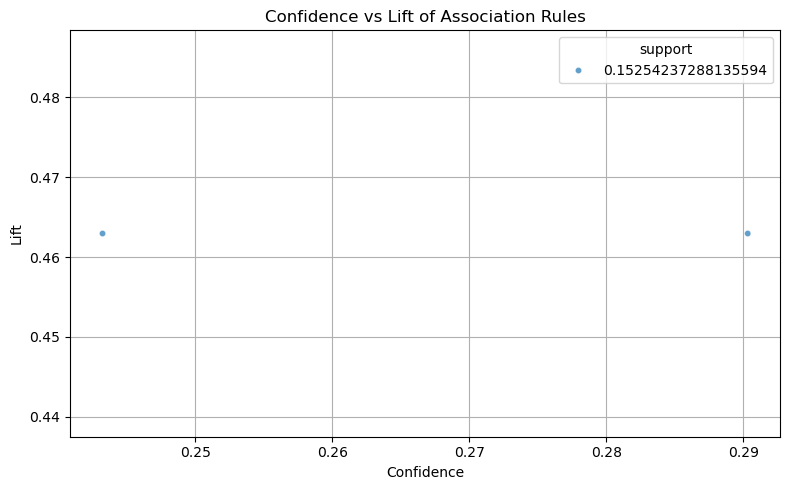

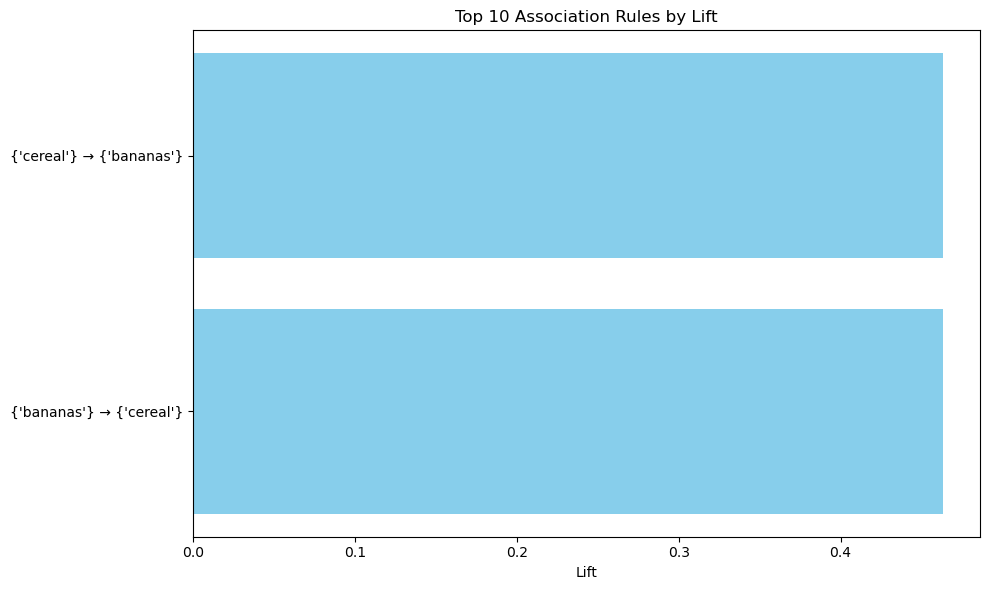

In [83]:
# mencari aturan asosiasi
from mlxtend.frequent_patterns import association_rules

# Buat aturan asosiasi dengan minimum confidence 0.1
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2)

print("\nAturan Asosiasi:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

# Visualisasi scatter plot confidence vs lift
plt.figure(figsize=(8, 5))
sns.scatterplot(data=rules, x='confidence', y='lift', size='support', sizes=(20, 200), alpha=0.7)
plt.title('Confidence vs Lift of Association Rules')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.grid(True)
plt.tight_layout()
plt.show()

# Visualisasi top 10 aturan berdasarkan lift
top_rules = rules.nlargest(10, 'lift')
plt.figure(figsize=(10, 6))
y_pos = range(len(top_rules))
plt.barh(y_pos, top_rules['lift'], color='skyblue')
plt.yticks(y_pos, [f"{set(row['antecedents'])} → {set(row['consequents'])}" for _, row in top_rules.iterrows()])
plt.xlabel('Lift')
plt.title('Top 10 Association Rules by Lift')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


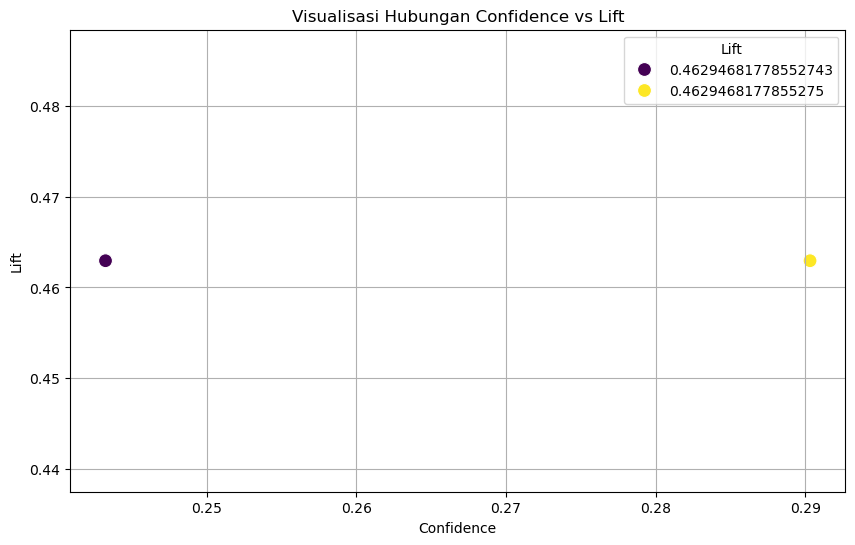

In [86]:
# Visualisasi hubungan lift dan confidence
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rules, x='confidence', y='lift', hue='lift', palette='viridis', s=100)
plt.title('Visualisasi Hubungan Confidence vs Lift')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.legend(title='Lift')
plt.grid(True)
plt.show()


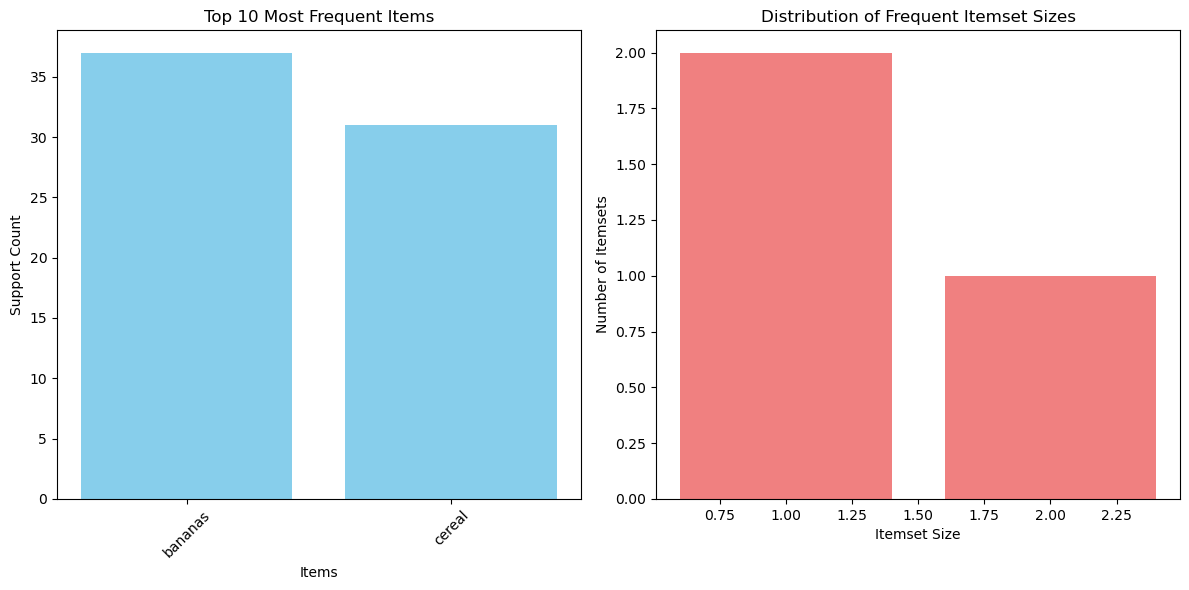


=== ANALISIS KESIMPULAN ===
Total transaksi: 153
Total item unik: 19
Total frequent itemsets: 3
Total association rules: 2

Top 10 Association Rules (berdasarkan lift):
cereal → bananas
  Support: 0.153, Confidence: 0.290, Lift: 0.463

bananas → cereal
  Support: 0.153, Confidence: 0.243, Lift: 0.463



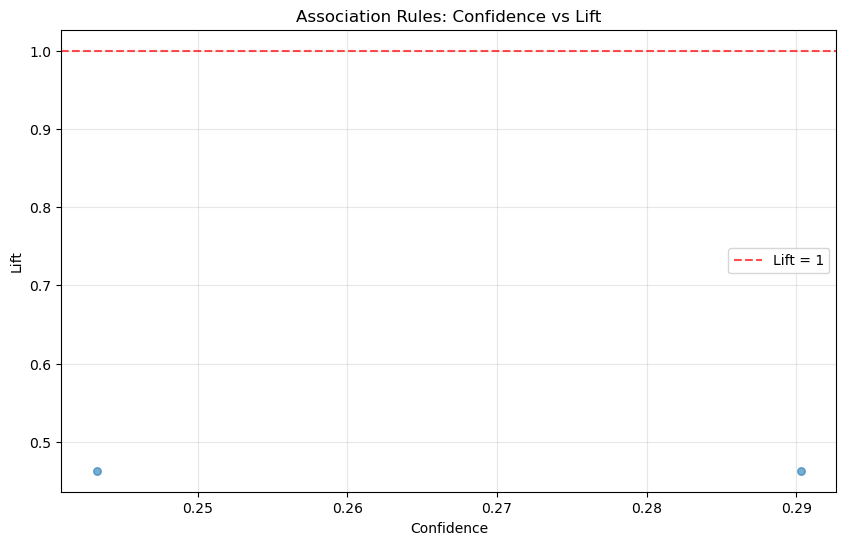

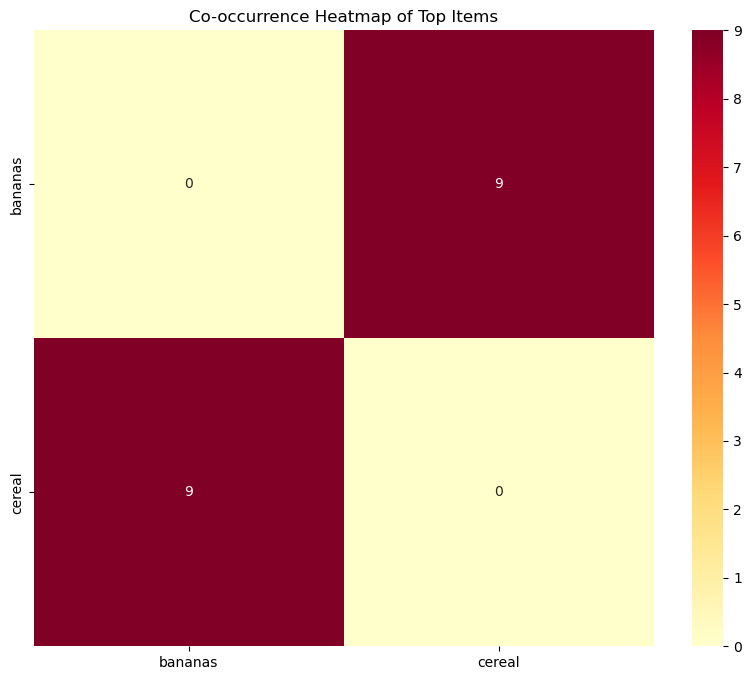


=== STATISTIK RINGKASAN ===
Rata-rata confidence: 0.267
Rata-rata lift: 0.463
Rata-rata support: 0.153
Jumlah rules dengan lift > 2: 0
Jumlah rules dengan confidence > 0.8: 0

=== REKOMENDASI BISNIS ===
1. Item yang sering dibeli bersama:
   - bananas, cereal (support: 9)

2. Strategi Cross-selling berdasarkan rules dengan lift tinggi:


In [92]:
# Tambahkan cell baru untuk analisis dan visualisasi kesimpulan
from collections import Counter

# 1. Visualisasi Top 10 Frequent Items
item_support = {}
for itemset, support in frequent_patterns.items():
    if len(itemset) == 1:
        item_support[list(itemset)[0]] = support

top_items = sorted(item_support.items(), key=lambda x: x[1], reverse=True)[:10]

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
items, supports = zip(*top_items)
plt.bar(items, supports, color='skyblue')
plt.title('Top 10 Most Frequent Items')
plt.xlabel('Items')
plt.ylabel('Support Count')
plt.xticks(rotation=45)

# 2. Distribusi Ukuran Itemsets
itemset_sizes = [len(itemset) for itemset in frequent_patterns.keys()]
size_counts = Counter(itemset_sizes)

plt.subplot(1, 2, 2)
sizes = list(size_counts.keys())
counts = list(size_counts.values())
plt.bar(sizes, counts, color='lightcoral')
plt.title('Distribution of Frequent Itemset Sizes')
plt.xlabel('Itemset Size')
plt.ylabel('Number of Itemsets')

plt.tight_layout()
plt.show()

# 3. Analisis Top Association Rules
print("\n=== ANALISIS KESIMPULAN ===")
print(f"Total transaksi: {len(transactions)}")
print(f"Total item unik: {len(set([item for transaction in transactions for item in transaction]))}")
print(f"Total frequent itemsets: {len(frequent_patterns)}")
print(f"Total association rules: {len(rules)}")

# Top 10 rules berdasarkan lift
top_rules = rules.nlargest(10, 'lift')
print("\nTop 10 Association Rules (berdasarkan lift):")
for idx, rule in top_rules.iterrows():
    antecedents = ', '.join(list(rule['antecedents']))
    consequents = ', '.join(list(rule['consequents']))
    print(f"{antecedents} → {consequents}")
    print(f"  Support: {rule['support']:.3f}, Confidence: {rule['confidence']:.3f}, Lift: {rule['lift']:.3f}")
    print()

# 4. Visualisasi Confidence vs Lift
plt.figure(figsize=(10, 6))
plt.scatter(rules['confidence'], rules['lift'], alpha=0.6, s=30)
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.title('Association Rules: Confidence vs Lift')
plt.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='Lift = 1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Heatmap untuk item co-occurrence
from itertools import combinations

# Buat matrix co-occurrence untuk top items
top_item_names = [item for item, _ in top_items[:8]]  # Ambil 8 item teratas
co_occurrence = np.zeros((len(top_item_names), len(top_item_names)))

for i, item1 in enumerate(top_item_names):
    for j, item2 in enumerate(top_item_names):
        if i != j:
            # Cari support untuk pasangan item
            pair = frozenset([item1, item2])
            if pair in frequent_patterns:
                co_occurrence[i][j] = frequent_patterns[pair]

plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence, 
            xticklabels=top_item_names, 
            yticklabels=top_item_names,
            annot=True, 
            fmt='.0f',
            cmap='YlOrRd')
plt.title('Co-occurrence Heatmap of Top Items')
plt.show()

# 6. Summary Statistics
print("\n=== STATISTIK RINGKASAN ===")
print(f"Rata-rata confidence: {rules['confidence'].mean():.3f}")
print(f"Rata-rata lift: {rules['lift'].mean():.3f}")
print(f"Rata-rata support: {rules['support'].mean():.3f}")
print(f"Jumlah rules dengan lift > 2: {len(rules[rules['lift'] > 2])}")
print(f"Jumlah rules dengan confidence > 0.8: {len(rules[rules['confidence'] > 0.8])}")

# 7. Rekomendasi Bisnis
print("\n=== REKOMENDASI BISNIS ===")
print("1. Item yang sering dibeli bersama:")
for itemset, support in list(frequent_patterns.items())[:10]:
    if len(itemset) >= 2:
        items_str = ', '.join(sorted(list(itemset)))
        print(f"   - {items_str} (support: {support})")

print("\n2. Strategi Cross-selling berdasarkan rules dengan lift tinggi:")
high_lift_rules = rules[rules['lift'] > 5].head(5)
for idx, rule in high_lift_rules.iterrows():
    antecedents = ', '.join(list(rule['antecedents']))
    consequents = ', '.join(list(rule['consequents']))
    print(f"   - Jika customer membeli {antecedents}, rekomendasikan {consequents}")
    print(f"     (Confidence: {rule['confidence']:.1%}, Lift: {rule['lift']:.2f})")

# (Optional) Tabu Search for Related Products (After Association Rules)


#### Setelah algoritma FP-Growth menghasilkan aturan asosiasi, Tabu Search digunakan untuk memilih dan mengurutkan produk yang paling relevan untuk setiap item. Proses ini bertujuan memaksimalkan skor gabungan dari beberapa faktor penting seperti support, confidence, dan lift, sambil tetap menjaga variasi produk yang direkomendasikan. Pada setiap iterasi, Tabu Search mengevaluasi beberapa kemungkinan perubahan (menambah, menghapus, atau menukar produk), dan menyimpan langkah-langkah yang baru digunakan dalam tabu list agar pencarian tidak berulang atau terjebak pada solusi yang kurang optimal. 

#### Hasil akhirnya adalah daftar produk terkait yang sudah terurut untuk setiap item, yang kemudian digunakan untuk menyaring aturan asosiasi sehingga rekomendasi menjadi lebih spesifik dan relevan.

In [90]:
import random
from collections import defaultdict, Counter

def craft_symmetric_pairs(rules, cap_rules=200000, pick_metric='lift'):
    """
    Bangun peta kandidat simetris dari aturan asosiasi.
    Tiap pasangan item (a,b) nyimpen support, confidence, lift terkumpul.
    """
    R = rules.copy()
    if pick_metric in R.columns:
        R = R.nlargest(cap_rules, pick_metric)
    pairbank = defaultdict(lambda: defaultdict(lambda: {'support':0.0,'confidence':0.0,'lift':0.0,'tally':0}))
    for _, row in R.iterrows():
        lefties = list(row['antecedents'])
        righties = list(row['consequents'])
        supp = row.get('support', 0.0)
        conf = row.get('confidence', 0.0)
        lift = row.get('lift', 1.0)
        for l in lefties:
            for r in righties:
                if l == r:
                    continue
                slot = pairbank[l][r]
                slot['support'] += supp
                slot['confidence'] += conf
                slot['lift'] += lift
                slot['tally'] += 1
                mirror = pairbank[r][l]
                mirror['support'] += supp
                mirror['confidence'] += conf
                mirror['lift'] += lift
                mirror['tally'] += 1
    for anchor, mates in pairbank.items():
        for mate, m in mates.items():
            c = max(m['tally'], 1)
            m['support'] /= c
            m['confidence'] /= c
            m['lift'] /= c
    return pairbank


def _minmax_scales(anchor, pairbank):
    """
    Hitung faktor min-max tiap metrik (support, confidence, lift)
    di antara tetangga item dasar.
    """
    buckets = {'support':[], 'confidence':[], 'lift':[]}
    for _, m in pairbank.get(anchor, {}).items():
        buckets['support'].append(m['support'])
        buckets['confidence'].append(m['confidence'])
        buckets['lift'].append(m['lift'])
    scales = {}
    for k, arr in buckets.items():
        if not arr:
            scales[k] = (0.0, 1.0)
        else:
            lo, hi = min(arr), max(arr)
            scales[k] = (lo, hi if hi > lo else lo + 1e-9)
    return scales


def rate_bundle(anchor, mates, pairbank, weights=(0.2,0.4,0.4)):
    """
    Skor daftar tetangga item pakai metrik ternormalisasi berbobot.
    """
    ws, wc, wl = weights
    scales = _minmax_scales(anchor, pairbank)
    total = 0.0
    for m in mates:
        slot = pairbank.get(anchor, {}).get(m)
        if not slot:
            continue
        def rescale(k, v):
            lo, hi = scales[k]
            return (v - lo) / (hi - lo) if hi > lo else 0.0
        total += ws*rescale('support', slot['support']) + wc*rescale('confidence', slot['confidence']) + wl*rescale('lift', slot['lift'])
    return total


def greedy_seed(anchor, pairbank, k, weights=(0.2,0.4,0.4)):
    """
    Solusi awal rakus: ambil top-k tetangga berdasar hasil kali support*confidence*lift.
    """
    buddies = list(pairbank.get(anchor, {}).items())
    if not buddies:
        return []
    ranked = sorted(buddies, key=lambda kv: (kv[1]['support']*kv[1]['confidence']*kv[1]['lift']), reverse=True)
    return [n for n,_ in ranked[:k]]

def tabu_hunt(anchor, pairbank, k=5, max_iter=100, tabu_span=7, weights=(0.2,0.4,0.4), seed=42):
    """
    ALGORITMA PENCARIAN TABU – Langkah demi Langkah
    ------------------------------------
    Tujuan: temukan k tetangga terbaik untuk item dasar.

    Langkah 0: Inisialisasi
    - Set seed biar hasil tetap sama.
    - Bikin solusi awal (rakus top-k).
    - Set best = saat ini, best_score = skor(saat ini).
    - Buat daftar tabu kosong (dict: item -> iterasi saat tabu habis).

    Langkah 1: Bangkitkan Calon Gerakan (Tetangga)
    Tiap iterasi:
    - Susun daftar kemungkinan gerakan:
        * TAMBAH:   pilih item yang belum ada lalu tambahkan (kalau |saat ini| < k).
        * HAPUS:    pilih item yang ada lalu buang.
        * TUKAR:    pilih satu ada & satu belum, lalu tukar.

    Langkah 2: Evaluasi Gerakan
    - Tiap gerakan, bikin solusi percobaan.
    - Hitung skornya.
    - Cek status tabu:
        * Kalau gerakan pakai item yg masih tabu (tenure > iterasi sekarang), itu tabu.
        * Gerakan tabu cuma diterima kalau bikin best_score naik (aspirasi).

    Langkah 3: Pilih Gerakan Non-Tabu Terbaik
    - Dari gerakan yg boleh, ambil skor tertinggi.
    - Kalau tak ada, berhenti cepat.

    Langkah 4: Perbarui
    - Terapkan gerakan pilihan ke solusi saat ini.
    - Masukkan item tersentuh ke daftar tabu dg tenure = iterasi + tabu_span.
    - Kalau skor baru lebih tinggi, update best & best_score.

    Langkah 5: Ulang
    - Ulang Langkah 1-4 sampai max_iter atau tak ada gerakan valid.

    Langkah 6: Pasca-proses
    - Urutkan lagi daftar best berdasar skor per item biar rapi.
    - Kembalikan daftar terurut & skornya.
    """
    random.seed(seed)
    # Langkah 0
    now = greedy_seed(anchor, pairbank, k, weights)
    best = list(now)
    best_score = rate_bundle(anchor, best, pairbank, weights)
    tabu = {}
    universe = set(pairbank.get(anchor, {}).keys())

    for it in range(1, max_iter+1):
        # Langkah 1: bangkitkan calon gerakan
        moves = []
        inside = set(now)
        outside = list(universe - inside)
        inside_list = list(inside)
        if len(now) < k and outside:
            moves.append(('add', random.choice(outside), None))
        if inside_list:
            moves.append(('remove', random.choice(inside_list), None))
        if inside_list and outside:
            moves.append(('swap', random.choice(inside_list), random.choice(outside)))

        # Langkah 2 & 3: evaluasi & pilih gerakan terbaik yg boleh
        top_move = None
        top_move_score = -1e9
        top_move_sol = None
        for mv, a, b in moves:
            trial = list(now)
            if mv == 'add':
                trial.append(a)
            elif mv == 'remove':
                trial = [x for x in trial if x != a]
            elif mv == 'swap':
                trial = [x for x in trial if x != a]
                trial.append(b)
            trial = trial[:k]
            sc = rate_bundle(anchor, trial, pairbank, weights)
            # cek tabu
            is_tabu = (mv=='add' and a in tabu and tabu[a] > it) or (mv=='remove' and a in tabu and tabu[a] > it) or (mv=='swap' and ((a in tabu and tabu[a] > it) or (b in tabu and tabu[b] > it)))
            if is_tabu and sc <= best_score:
                continue  # lewati gerakan tabu kecuali bikin best_score naik
            if sc > top_move_score:
                top_move_score = sc
                top_move = (mv, a, b)
                top_move_sol = trial

        # Langkah 4: terapkan gerakan
        if top_move_sol is None:
            break  # tak ada gerakan valid
        mv, a, b = top_move
        now = top_move_sol
        touched = [a] if b is None else [a,b]
        for t in touched:
            tabu[t] = it + tabu_span
        if top_move_score > best_score:
            best = list(now)
            best_score = top_move_score

    # Langkah 6: urutkan lagi best berdasar skor individu
    solo_scores = [(n, rate_bundle(anchor, [n], pairbank, weights)) for n in best]
    solo_scores.sort(key=lambda x: x[1], reverse=True)
    return [n for n,_ in solo_scores], best_score

def optimize_all_items(pairbank, k=5, max_iter=100, tabu_span=7, weights=(0.2,0.4,0.4), cap_items=None):
    """
    Jalankan pencarian tabu tiap item dasar (atau daftar terbatas) & kumpulkan hasil.
    """
    outcome = {}
    anchors = list(pairbank.keys()) if cap_items is None else [b for b in pairbank.keys() if b in cap_items]
    for i, anchor in enumerate(anchors):
        best_list, best_score = tabu_hunt(anchor, pairbank, k=k, max_iter=max_iter, tabu_span=tabu_span, weights=weights, seed=42+i)
        outcome[anchor] = {'related': best_list, 'score': best_score}
    return outcome


def prune_via_tabu(rules, tabu_related):
    """
    Saring aturan asosiasi: tiap item anteseden,
    semua konsekuen harus ada di daftar tabu-terkaitnya (kalau daftar ada).
    """
    def keep(row):
        lefties = list(row['antecedents'])
        righties = list(row['consequents'])
        for l in lefties:
            rel = set(tabu_related.get(l, {}).get('related', []))
            if rel and not set(righties).issubset(rel):
                return False
        return True
    return rules[rules.apply(keep, axis=1)].copy()
